# E COMMERCES SALES ANALYSIS 

## IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df=pd.read_csv("C:/Users/HP/OneDrive/data analyst project dataset/E COMMERCES-DATASET/messy_ecommerce_sales_data.csv")

In [5]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,total
0,100,Customer_100,ORD-41285,22-11-2024,Blender,Home,3,38.00,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,05-07-2025,Smartphone,Electronics,2,0.00,PayPal,Processing,0.00
2,102,Customer_102,ORD-84355,23-12-2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,19-03-2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,20-10-2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [6]:
df.tail()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,total
95,195,Customer_195,ORD-82876,19-06-2025,Biography,Books,5,817.46,Cash on Delivery,Returned,4087.30
96,196,Customer_196,ORD-78384,23-12-2024,Vacuum,Home,0,0.00,PayPal,Delivered,0.00
97,197,Customer_197,ORD-79139,23-06-2025,Blender,Home,1,160.16,PayPal,Cancelled,160.16
98,198,Customer_198,ORD-14608,27-07-2025,Vacuum,Home,2,497.01,Cash on Delivery,Shipped,994.02
99,199,Customer_199,ORD-82922,22-01-2025,Blender,Home,5,372.28,Credit Card,Shipped,1861.40


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              100 non-null    int64  
 1    Customer_Name  100 non-null    object 
 2   Order_ID        100 non-null    object 
 3   Order_Date      99 non-null     object 
 4   Product         100 non-null    object 
 5    Category       99 non-null     object 
 6   Quantity        100 non-null    int64  
 7   Price           100 non-null    float64
 8   Payment_Method  100 non-null    object 
 9   Status          100 non-null    object 
 10  total           100 non-null    float64
dtypes: float64(2), int64(2), object(7)
memory usage: 8.7+ KB


In [9]:
df.shape

(100, 11)

In [10]:
df.columns

Index(['ID', ' Customer_Name', 'Order_ID', 'Order_Date', 'Product',
       ' Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'total'],
      dtype='object')

In [12]:
df.describe()

,ID,Quantity,Price,total
count,100.000000,100.000000,100.000000,100.000000
mean,149.500000,2.960000,575.165075,1614.882250
std,29.011492,1.569404,991.903238,2198.446587
min,100.000000,0.000000,0.000000,0.000000
25%,124.750000,2.000000,240.705000,528.800000
50%,149.500000,3.000000,513.035000,1127.180000
75%,174.250000,4.250000,711.795000,2072.540000
max,199.000000,5.000000,10000.000000,20000.000000


In [17]:
print(df.dtypes)

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity            int64
Price             float64
Payment_Method     object
Status             object
total             float64
dtype: object


## data cleaning 

#### missing values

In [18]:
df.isnull().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        1
Product           0
 Category         1
Quantity          0
Price             0
Payment_Method    0
Status            0
total             0
dtype: int64

In [22]:
print(df[df["Order_Date"].isnull()])

     ID  Customer_Name   Order_ID Order_Date Product  Category  Quantity  \
92  192   Customer_192  ORD-35144        NaN  Jacket  Clothing         4   

     Price Payment_Method    Status   total  
92  203.63    Credit Card  Returned  814.52  


In [28]:
df.loc[df["Order_Date"].isnull(), "Order_Date"] = "10-11-2025"


In [25]:
df.isnull().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         1
Quantity          0
Price             0
Payment_Method    0
Status            0
total             0
dtype: int64

In [26]:
print(df[df[" Category"].isnull()])

     ID  Customer_Name   Order_ID  Order_Date    Product  Category  Quantity  \
33  133   Customer_133  ORD-68182  05-12-2024  Biography       NaN         5   

     Price Payment_Method   Status   total  
33  343.24    Credit Card  Shipped  1716.2  


In [29]:
df.loc[df[" Category"].isnull(), " Category"] = "Book"

In [30]:
df.isnull().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         0
Quantity          0
Price             0
Payment_Method    0
Status            0
total             0
dtype: int64

#### duplicates

#### datatype 

In [37]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity            int64
Price             float64
Payment_Method     object
Status             object
total             float64
dtype: object

In [34]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

In [35]:
df.dtypes

ID                         int64
 Customer_Name            object
Order_ID                  object
Order_Date        datetime64[ns]
Product                   object
 Category                 object
Quantity                   int64
Price                    float64
Payment_Method            object
Status                    object
total                    float64
dtype: object

# final data cleaning check

In [36]:
df.isnull().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         0
Quantity          0
Price             0
Payment_Method    0
Status            0
total             0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.dtypes

ID                         int64
 Customer_Name            object
Order_ID                  object
Order_Date        datetime64[ns]
Product                   object
 Category                 object
Quantity                   int64
Price                    float64
Payment_Method            object
Status                    object
total                    float64
dtype: object

# Exploratory Data Analysis

## key business questions

In [47]:
### 1. Which category has highest salas?
df.groupby(" Category")["total"].sum().sort_values(ascending=False).head(1)

 Category
Books    38357.11
Name: total, dtype: float64

In [48]:
### 2. Which products are frequently cancelled?
df[df["Status"] == "Cancelled"]["Product"].value_counts()

Product
Comics           2
Smartphone       2
Blender          2
Tennis Racket    1
Basketball       1
Yoga Mat         1
Vacuum           1
Shoes            1
Smartwatch       1
T-shirt          1
Biography        1
Football         1
Name: count, dtype: int64

In [51]:
### 3. Which payment method is most used?
df["Payment_Method"].value_counts()

Payment_Method
Cash on Delivery    33
PayPal              24
Bank Transfer       22
Credit Card         21
Name: count, dtype: int64

In [50]:
### 4.Which orders are returned most?
df[df["Status"] == "Returned"]["Order_ID"].value_counts()

Order_ID
ORD-89122    1
ORD-23010    1
ORD-69764    1
ORD-35144    1
ORD-41810    1
ORD-30627    1
ORD-41292    1
ORD-20916    1
ORD-89906    1
ORD-64136    1
ORD-16766    1
ORD-48008    1
ORD-75539    1
ORD-27743    1
ORD-72349    1
ORD-96037    1
ORD-20182    1
ORD-72869    1
ORD-76902    1
ORD-38423    1
ORD-75314    1
ORD-45059    1
ORD-67096    1
ORD-48863    1
ORD-65482    1
ORD-72778    1
ORD-82876    1
Name: count, dtype: int64

In [54]:
### 5. Which month has highest revenue?
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df.groupby(df["Order_Date"].dt.to_period("M"))["total"].sum().sort_values(ascending=False).head(1)

Order_Date
2025-02    40278.98
Freq: M, Name: total, dtype: float64

In [56]:
### 6.How many invalid/missing records exist?
df.isnull().sum()
df.isnull().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         0
Quantity          0
Price             0
Payment_Method    0
Status            0
total             0
dtype: int64

In [57]:
df[df["total"] < 0]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,total


In [62]:
### 7. Which categories generate top 4 profit? 
df.groupby(" Category")["total"].sum().sort_values(ascending=False).head(2)

 Category
Books       38357.110
Clothing    30283.195
Name: total, dtype: float64

In [63]:
### 8.Electronics generate profit?
df[df[" Category"] == "Electronics"]["total"].sum()

np.float64(12365.279999999999)

# Key Performance Indicator

#### total sales

In [64]:
print("Total Sales:", df["total"].sum())

Total Sales: 161488.225


#### total orders

In [65]:
print("Total Orders:", df["Order_ID"].nunique())

Total Orders: 100


#### Cancelled Orders

In [66]:
print("Cancelled Orders:", df[df["Status"] == "Cancelled"].shape[0])

Cancelled Orders: 15


#### Returned Orders

In [67]:
print("Returned Orders:", df[df["Status"] == "Returned"].shape[0])

Returned Orders: 27


#### Average Order Value (AOV)

In [68]:
print("Average Order Value:", df["total"].sum() / df["Order_ID"].nunique())

Average Order Value: 1614.88225


 #### Top Category

In [70]:
top_category = df.groupby(" Category")["total"].sum().idxmax()
print("Top Category:", top_category)

Top Category: Books


#### Revenue by Payment Method

In [71]:
print("Revenue by Payment Method:")
print(df.groupby("Payment_Method")["total"].sum())

Revenue by Payment Method:
Payment_Method
Bank Transfer       41663.425
Cash on Delivery    67080.230
Credit Card         24642.130
PayPal              28102.440
Name: total, dtype: float64


#### Monthly-year Sales

In [74]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["total"].sum()

print("Monthly Sales (Sorted by Month-Year):")
print(monthly_sales.sort_index())

Monthly Sales (Sorted by Month-Year):
Order_Date
2023-01     1532.040
2023-05     1721.980
2024-11    11373.945
2024-12     7027.810
2025-01    11851.430
2025-02    40278.980
2025-03     5675.860
2025-04     1200.280
2025-05    10959.030
2025-06    18398.450
2025-07    15092.800
2025-08     6137.040
2025-09     7471.680
2025-10    20569.000
2025-11     2197.900
Freq: M, Name: total, dtype: float64


# CHART REQUIREMENT

## 1.Monthly sales trend

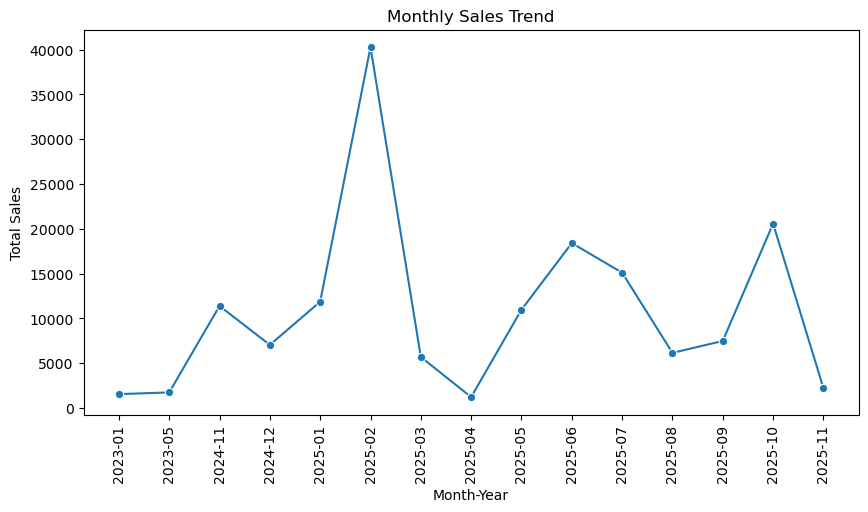

In [ ]:
# Convert date column
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month-Year column
df["Month_Year"] = df["Order_Date"].dt.strftime("%Y-%m")

# Group data
monthly_sales = df.groupby("Month_Year")["total"].sum().reset_index()

# Sort properly
monthly_sales = monthly_sales.sort_values("Month_Year")

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x="Month_Year", y="total", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

## 2.category wise revenue analysis

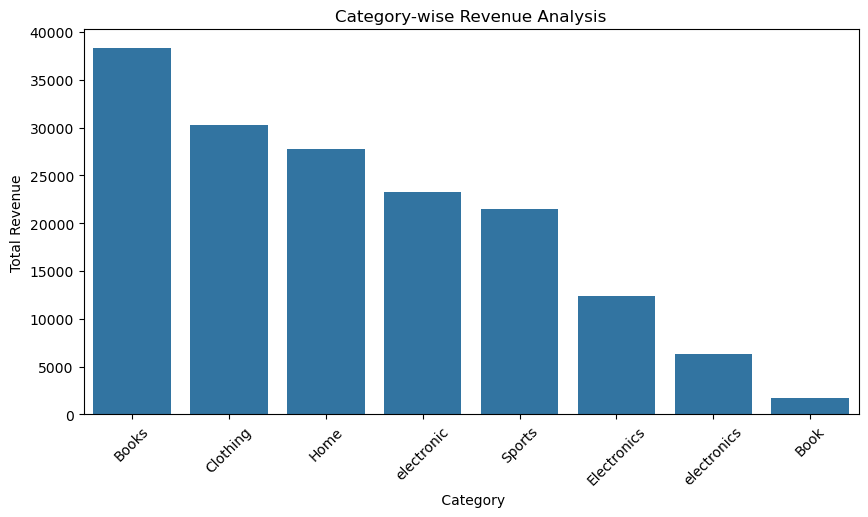

In [95]:
category_sales = df.groupby(" Category")["total"].sum().reset_index()
category_sales = category_sales.sort_values("total", ascending=False)
plt.figure(figsize=(10,5))

sns.barplot(data=category_sales, x=" Category", y="total")

plt.title("Category-wise Revenue Analysis")
plt.xlabel(" Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

## 2. category wise product count

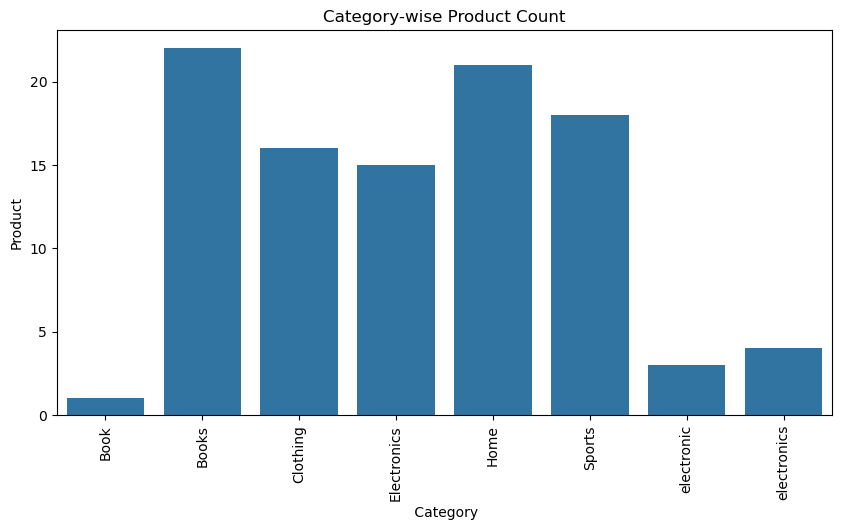

In [88]:
cat_prod_count = df.groupby(" Category")["Product"].count().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=cat_prod_count, x=" Category", y="Product")

plt.title("Category-wise Product Count")
plt.xticks(rotation=90)

plt.show()

## 3.order status analysis


       Status  Count
0    Returned     27
1  Processing     25
2     Shipped     22
3   Cancelled     15
4   Delivered     11


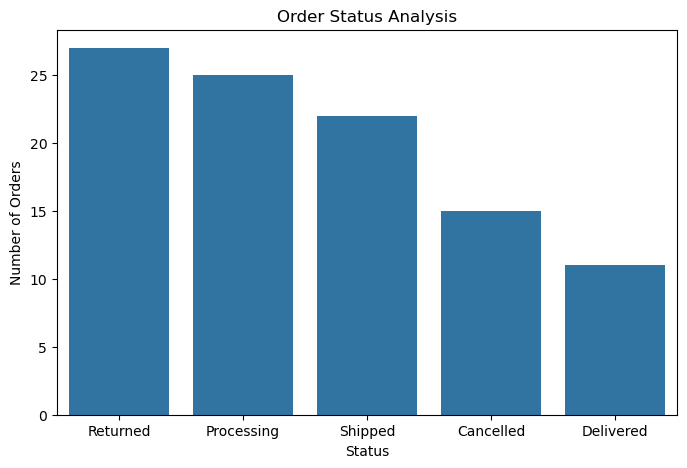

In [91]:
status_count = df["Status"].value_counts().reset_index()
status_count.columns = ["Status", "Count"]
print(status_count)
plt.figure(figsize=(8,5))

sns.barplot(data=status_count, x="Status", y="Count")

plt.title("Order Status Analysis")
plt.xlabel("Status")
plt.ylabel("Number of Orders")

plt.show()

## 4.payment method distribution

     Payment_Method  Count
0  Cash on Delivery     33
1            PayPal     24
2     Bank Transfer     22
3       Credit Card     21


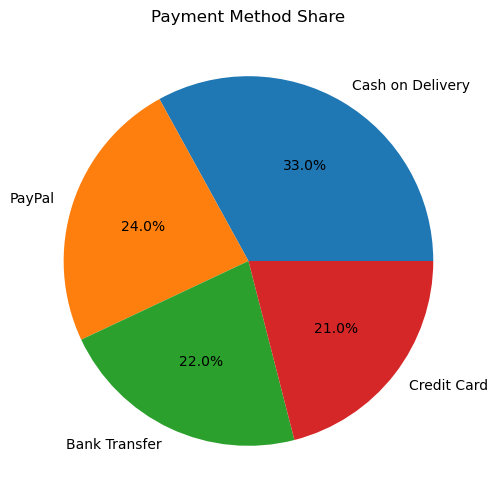

In [93]:
payment_count = df["Payment_Method"].value_counts().reset_index()
payment_count.columns = ["Payment_Method", "Count"]

print(payment_count)
plt.figure(figsize=(6,6))

plt.pie(payment_count["Count"], labels=payment_count["Payment_Method"], autopct="%1.1f%%")

plt.title("Payment Method Share")

plt.show()

## 5.product performances ranking

       Product     total
2      Blender  28075.38
3       Comics  14728.64
13       Shoes  14687.72
9         Lamp  14306.44
1    Biography   9577.39
0   Basketball   8953.72
16     T-shirt   8230.26
12     Science   8005.71
4      Fiction   7761.57
11   Microwave   6601.51


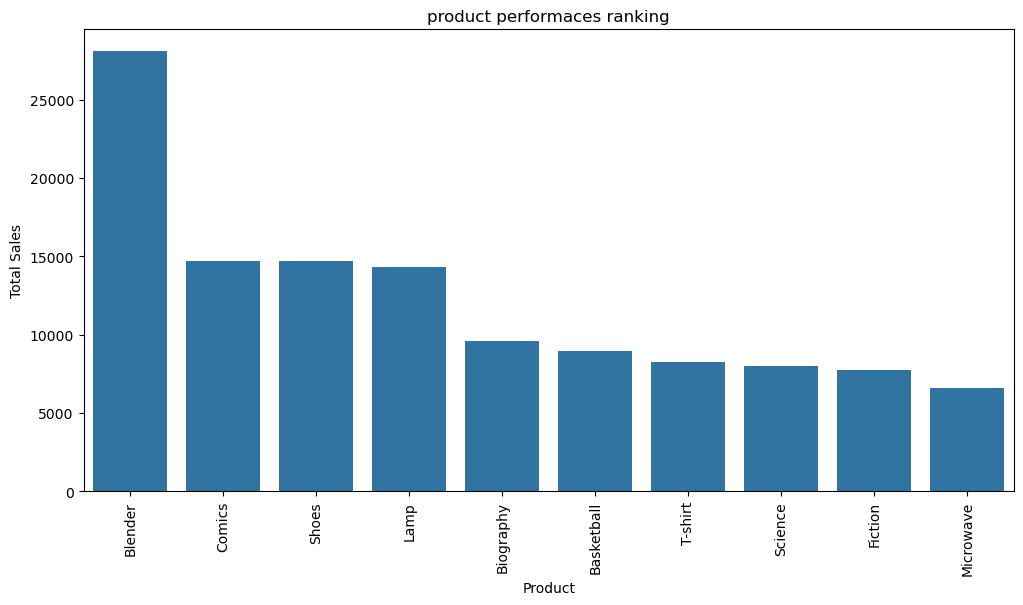

In [ ]:
product_sales = df.groupby("Product")["total"].sum().reset_index()
product_sales = product_sales.sort_values("total", ascending=False)
print(product_sales.head(10))
top10 = product_sales.head(10)

plt.figure(figsize=(12,6))

sns.barplot(data=top10, x="Product", y="total")

plt.title("product performaces ranking")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.show()
